<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/06-09-opneCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from torchvision.io import read_image
from torchvision.transforms import v2

In [2]:
img_tensor=read_image("sample_data/num_random_0.jpg")
img_tensor

tensor([[[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255]]], dtype=torch.uint8)

In [3]:
import torch
# 이미지를 흑백으로 변환
to_gray=v2.Compose([
    v2.Grayscale(num_output_channels=1)
])

gray=to_gray(img_tensor)
print(gray)
print('텐서 크기 :', gray.shape)

tensor([[[254, 254, 254,  ..., 254, 254, 254],
         [254, 254, 254,  ..., 254, 254, 254],
         [254, 254, 254,  ..., 254, 254, 254],
         ...,
         [254, 254, 254,  ..., 254, 254, 254],
         [254, 254, 254,  ..., 254, 254, 254],
         [254, 254, 254,  ..., 254, 254, 254]]], dtype=torch.uint8)
텐서 크기 : torch.Size([1, 100, 600])


In [4]:
# from torchvision.transforms.v2 import functional as F

In [5]:
threshold_value=0.5

# 텐서값 확인 - 0.5보다 작냐 크냐
binary=(gray < threshold_value).float()
# True -> 어두운곳
print('텐서 크기 :', binary.shape)
print(binary)

# 이진화 => 물체 마스킹 등 작업(글씨랑 배경만 분리하기 위)

텐서 크기 : torch.Size([1, 100, 600])
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


In [6]:
import cv2
import numpy as np

# 파이토치 텐서 -> numpy 배열 변환
# OpenCV는 파이토치 텐서 직접 처리 불가능 - 채널 차원이 없어야한다
# [1,100,600] -> [100,600]
# OpneCV 표준 (0~255)
binary_numpy=(binary.squeeze().cpu().numpy()*255).astype(np.uint8)

# 외곽선좌표들,                                    가장 바깥쪽 외곽선만 검출, 압축 알고리즘
contours, hierarchy=cv2.findContours(binary_numpy, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

print('컴풀된 컨투어 수 :', len(contours))

# 이미지 안에서 배경이랑 분리된 개수가 10개 검출되었다!

컴풀된 컨투어 수 : 10


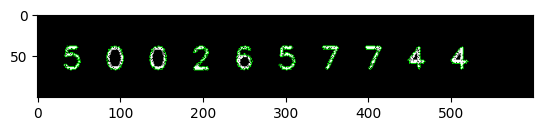

In [7]:
import matplotlib.pyplot as plt

visual_img=cv2.cvtColor(binary_numpy, cv2.COLOR_GRAY2RGB)
                                           # RGB     두께
cv2.drawContours(visual_img, contours, -1, (0,255,0),1)

plt.imshow(visual_img)
plt.show()

In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform=transforms.ToTensor()

train_dataset=datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset=datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 데이터 로더
train_loader=DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

train_dataset=datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset=datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 데이터 로더
train_loader=DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False)

In [10]:
# CNN 코드 구현해서 성능평가 뽑기

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Conv2D: 입력 채널(1), 출력 채널(32), 커널 사이즈(3)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        # MaxPool2D: 2x2 사이즈
        self.pool = nn.MaxPool2d(2, 2)

        # Flatten 후 Dense(Linear) 레이어
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # 첫 번째 블록: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # 두 번째 블록: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten
        x = x.view(-1, 64 * 5 * 5)

        # Dense 블록
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.log_softmax(self.fc2(x), dim=1) # 최종 출력
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

print(f"현재 사용 중인 장치: {device}")

현재 사용 중인 장치: cuda


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from tqdm import tqdm

# 모델 저장 디렉토리 생성
os.makedirs('model', exist_ok=True)


epochs = 100
patience = 5
best_loss = float('inf')
counter = 0
model_file_name = 'model/project7_Number.pth'


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.to(device)
model.train()

for epoch in range(epochs):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    train_loss = 0.0

    for images, labels in loop:
        optimizer.zero_grad()
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))


        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())


    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            val_loss += criterion(outputs, labels.to(device)).item()

    val_loss /= len(test_loader)
    print(f"Validation Loss: {val_loss:.4f}")


    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), model_file_name)
        print("Best model")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch 1/100: 100%|██████████| 938/938 [00:19<00:00, 48.82it/s, loss=0.171]


Validation Loss: 0.0492
Best model


Epoch 2/100: 100%|██████████| 938/938 [00:17<00:00, 54.53it/s, loss=0.0212]


Validation Loss: 0.0333
Best model


Epoch 3/100: 100%|██████████| 938/938 [00:19<00:00, 49.15it/s, loss=0.0212]


...

Validation Loss: 0.0324


Epoch 9/100: 100%|██████████| 938/938 [00:17<00:00, 53.45it/s, loss=0.000589]


Validation Loss: 0.0401


Epoch 10/100: 100%|██████████| 938/938 [00:17<00:00, 53.58it/s, loss=0.0092]


Validation Loss: 0.0448
Early stopping triggered!


In [15]:

train_losses = []
val_losses = []


for epoch in range(epochs):
    model.train()
    train_loss_sum = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()

    train_losses.append(train_loss_sum / len(train_loader))


    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            val_loss_sum += criterion(outputs, labels.to(device)).item()

    val_losses.append(val_loss_sum / len(test_loader))

    print(f"Epoch {epoch+1} 완료 - Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

Epoch 1 완료 - Train Loss: 0.0179, Val Loss: 0.0393
Epoch 2 완료 - Train Loss: 0.0115, Val Loss: 0.0316
Epoch 3 완료 - Train Loss: 0.0087, Val Loss: 0.0385
Epoch 4 완료 - Train Loss: 0.0095, Val Loss: 0.0366
Epoch 5 완료 - Train Loss: 0.0084, Val Loss: 0.0368
Epoch 6 완료 - Train Loss: 0.0074, Val Loss: 0.0343
Epoch 7 완료 - Train Loss: 0.0068, Val Loss: 0.0456
Epoch 8 완료 - Train Loss: 0.0072, Val Loss: 0.0398
Epoch 9 완료 - Train Loss: 0.0063, Val Loss: 0.0483
Epoch 10 완료 - Train Loss: 0.0067, Val Loss: 0.0369
Epoch 11 완료 - Train Loss: 0.0045, Val Loss: 0.0471
Epoch 12 완료 - Train Loss: 0.0054, Val Loss: 0.0453
Epoch 13 완료 - Train Loss: 0.0047, Val Loss: 0.0424
Epoch 14 완료 - Train Loss: 0.0060, Val Loss: 0.0459
Epoch 15 완료 - Train Loss: 0.0060, Val Loss: 0.0381
Epoch 16 완료 - Train Loss: 0.0048, Val Loss: 0.0451
Epoch 17 완료 - Train Loss: 0.0046, Val Loss: 0.0529
Epoch 18 완료 - Train Loss: 0.0051, Val Loss: 0.0450
Epoch 19 완료 - Train Loss: 0.0046, Val Loss: 0.0492
Epoch 20 완료 - Train Loss: 0.0039, Val Lo

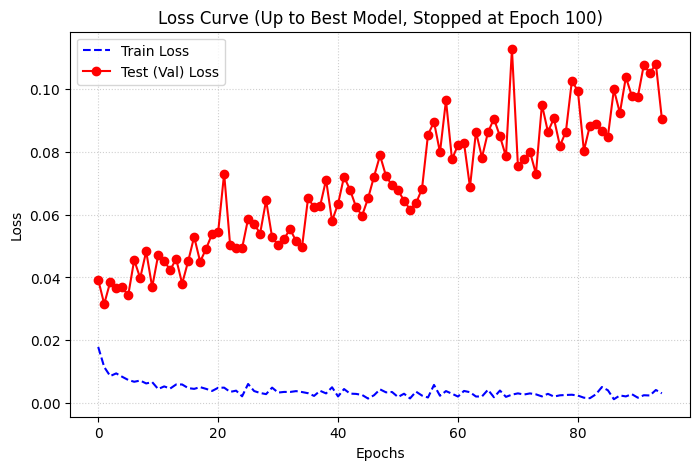

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

if counter >= patience:
    plt.plot(train_losses[:-patience], label='Train Loss', color='blue', linestyle='--')
    plt.plot(val_losses[:-patience], label='Test (Val) Loss', color='red', marker='o')
    plt.title(f'Loss Curve (Up to Best Model, Stopped at Epoch {len(train_losses)})')
else:
    plt.plot(train_losses, label='Train Loss', color='blue', linestyle='--')
    plt.plot(val_losses, label='Test (Val) Loss', color='red', marker='o')
    plt.title('Loss Curve (All Epochs Completed)')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [17]:
import cv2
import os

img_paths=[os.path.join('sample_data/', f'num_random_{i}.jpg') for i in range(10)]
img_paths

['sample_data/num_random_0.jpg',
 'sample_data/num_random_1.jpg',
 'sample_data/num_random_2.jpg',
 'sample_data/num_random_3.jpg',
 'sample_data/num_random_4.jpg',
 'sample_data/num_random_5.jpg',
 'sample_data/num_random_6.jpg',
 'sample_data/num_random_7.jpg',
 'sample_data/num_random_8.jpg',
 'sample_data/num_random_9.jpg']

In [19]:
import torch


best_model = SimpleCNN()

state_dict = torch.load(model_file_name, map_location=device)

best_model.load_state_dict(state_dict)


best_model.to(device)

best_model.eval()

print(f"{model_file_name}")

model/project7_Number.pth


5 0 0 2 6 5 7 7 4 4 총합 :  40


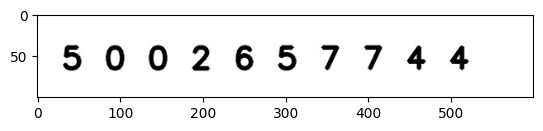

2 8 7 1 4 2 2 7 1 3 총합 :  37


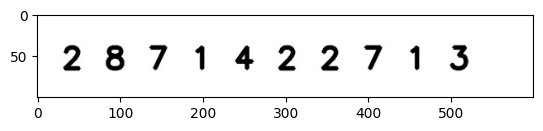

3 3 2 0 4 1 9 0 2 6 총합 :  30


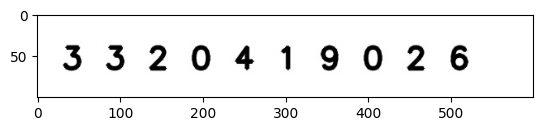

8 3 1 0 6 7 9 8 8 3 총합 :  53


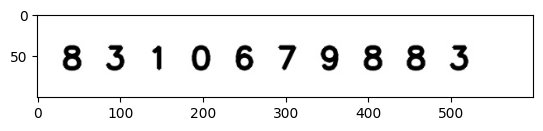

4 8 1 3 6 7 6 0 6 5 총합 :  46


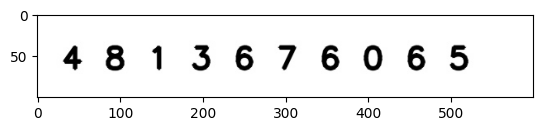

2 4 2 9 6 2 3 7 0 8 총합 :  43


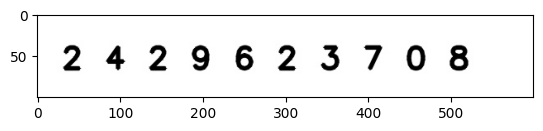

8 4 0 9 5 7 2 4 8 6 총합 :  53


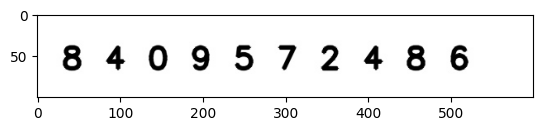

1 1 7 5 7 4 5 3 9 1 총합 :  43


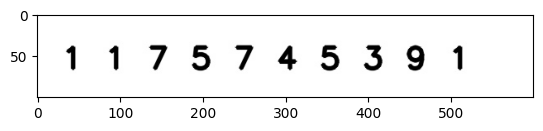

4 7 8 1 1 6 5 3 5 4 총합 :  44


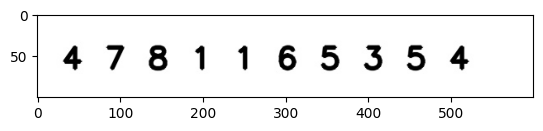

2 5 9 6 1 8 7 7 3 2 총합 :  50


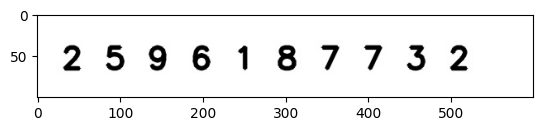

In [23]:
# 이미지 로드 -> opneCV 검출 -> 파이토치 전처리/예측 -> 합산
for i, path in enumerate(img_paths):
  img=cv2.imread(path)
  gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # 이미지의 미세한 노이즈 삭제 -> 정확도 높이기 위해
  # 커널 크기는 홀수로 -> 픽셀들의 정중앙에 지운 픽셀이 위치해야한다
  # 명암분석
  blurred=cv2.GaussianBlur(gray, (5,5),0)


  # THRESH_OTSU : CV 이진화처리에 많이 사용하는 알고리즘

  # THRESH_BINARY_INV : 임계값 자동계산(배경 물체가 갈라지는 최적의 기준점)
  # THRESH_OTSU : 오츠가 찾은 기준점보다 어두우면 255(흰색), 밝은 곳은 0(검은색)

  mean_bright=np.mean(blurred)
  if mean_bright >127:
    _, threshold=cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
  else :
    _, threshold=cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

  # 외곽선 좌표
  contours,_=cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  # 숫자의 시작 X좌표 반환
  contours=sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

  # 숫자 저장하려고
  extract_numbers=[]

  for i in contours:
      # 윤곽선 감싸는 사각형의 좌표와 크기 추출함
      x,y,w,h = cv2.boundingRect(i)

      # 너무 작거나 큰 네모는 노이즈이므로 사용하지 않는다.
      if w<5 or h<15:
          continue

      # ROI(Region of Interest : 관심영역)
      # 오츠 이진화를 거친 이미지를 기준으로 자름(세로축, 가로축 슬라이싱)
      roi=threshold[y:y+h, x:x+w]

      # w, h 중 더 긴 쪽을 기준으로 잡아 여백확복
      side=max(w,h)+20

      # 빈 도화지 만듬(정사각형)
      digit_can=np.zeros((side, side), dtype=np.uint8)


      digit_can[(side-h) // 2 : (side-h) // 2 + h, (side-w) // 2 : (side-w) // 2 + w] = roi

      # 28*28로 축소함 -> 픽셀 무너지지 않게 유지
      final_roi = cv2.resize(digit_can, (28, 28), interpolation=cv2.INTER_AREA)

      # 이미지를 0.0~1.0 tkdl - 실수 데이터로 변환
      roi_tensor=torch.tensor(final_roi, dtype=torch.float32)/255.0

      # 모델 왜곡 방지하기 위해 정규화 (z-score 정규화 공식에서)
      roi_tensor=(roi_tensor-0.1307)/0.3081

      # 배치, 채널, 세로, 가로
      # [1,1,28,28]
      roi_tensor=roi_tensor.unsqueeze(0).unsqueeze(0)

      with torch.no_grad():
        outputs=best_model(roi_tensor.to(device))
        _, predicted=torch.max(outputs, 1)
        result_num=predicted.item()

      extract_numbers.append(result_num)


  for i in extract_numbers:
    print(i, end=' ')

  print('총합 : ', np.sum(extract_numbers))

  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.show()